Saving edges.csv to edges (3).csv
Loaded edges: (20744, 2)
Number of nodes: 15060
Number of edges: 20507


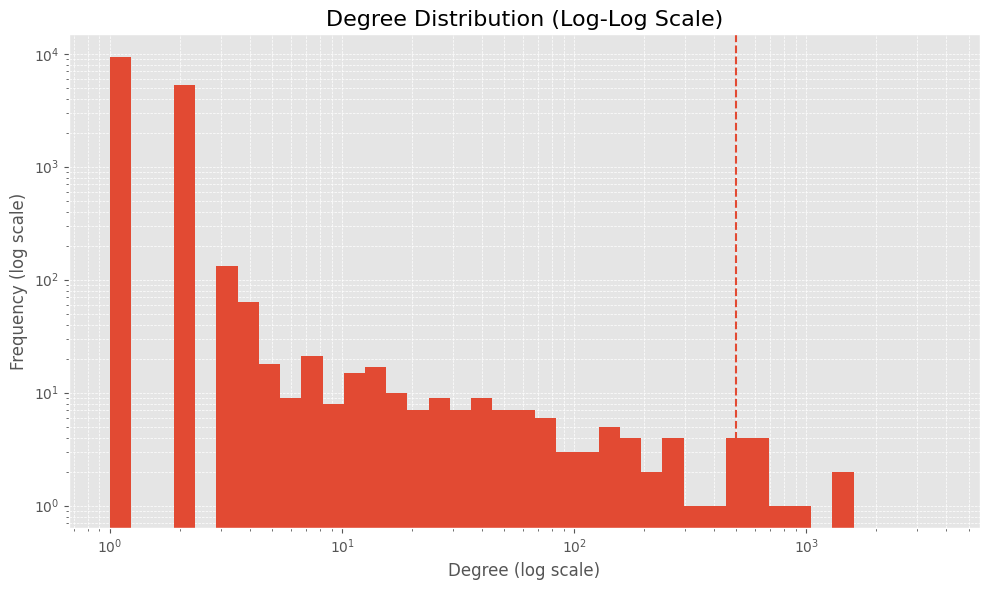

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

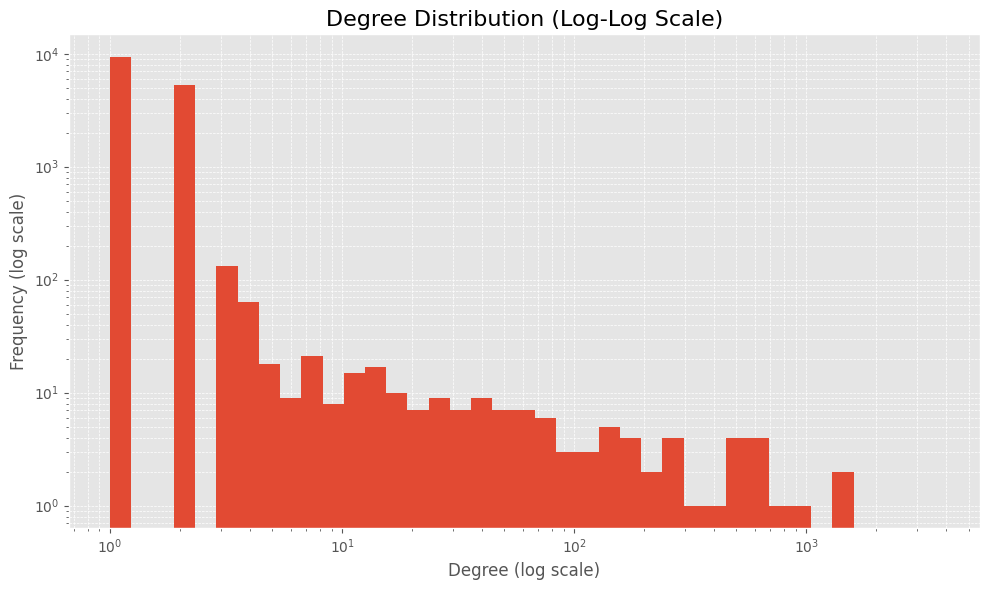

In [7]:
# ================================
# Step 1: Upload file
# ================================
from google.colab import files
uploaded = files.upload()

# ================================
# Step 2: Load data
# ================================
import pandas as pd

edges = pd.read_csv("edges.csv")
print("Loaded edges:", edges.shape)

# ================================
# Step 3: Build graph
# ================================
import networkx as nx

G = nx.from_pandas_edgelist(edges, "Source", "Target")

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# ================================
# Step 4: Compute degrees
# ================================
degrees = [d for n, d in G.degree()]

# ================================
# Step 5: Plot (CLEAN VERSION)
# ================================
import matplotlib.pyplot as plt
import numpy as np

# Apply ggplot style
plt.style.use('ggplot')

# Convert to numpy and remove zeros
degrees = np.array(degrees)
degrees = degrees[degrees > 0]

# Create log-spaced bins
bins = np.logspace(np.log10(min(degrees)), np.log10(max(degrees)), 40)

plt.figure(figsize=(10,6))
plt.hist(degrees, bins=bins)

# Log-log scale (IMPORTANT)
plt.xscale("log")
plt.yscale("log")

# Labels + title
plt.title("Degree Distribution (Log-Log Scale)", fontsize=16)
plt.xlabel("Degree (log scale)", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)

# Grid for readability
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Optional: highlight hub region
plt.axvline(x=500, linestyle='--')

plt.tight_layout()
plt.show()

# ================================
# Step 6: Save image for slides
# ================================
plt.figure(figsize=(10,6))
plt.hist(degrees, bins=bins)
plt.xscale("log")
plt.yscale("log")

plt.title("Degree Distribution (Log-Log Scale)", fontsize=16)
plt.xlabel("Degree (log scale)", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)

plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=300)

# ================================
# Step 7: Download
# ================================
files.download("degree_distribution.png")

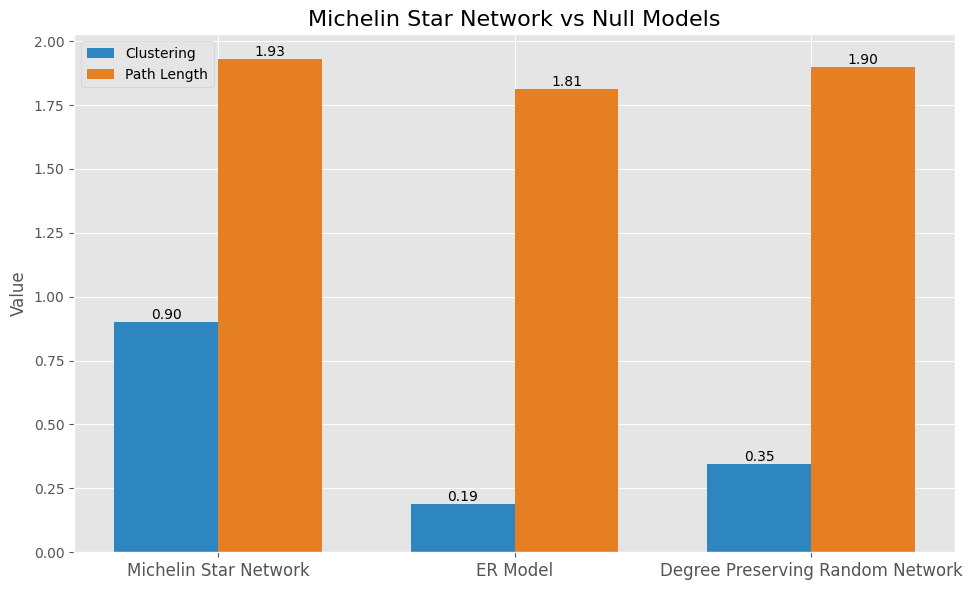

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')


labels = ['Michelin Star Network', 'ER Model', 'Degree Preserving Random Network']

clustering = [0.90, 0.1881, 0.3456]
path_length = [1.93, 1.8119, 1.8991]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Colors
colors1 = ['#2E86C1'] * 3  # blue
colors2 = ['#E67E22'] * 3  # orange

# Bars
bars1 = ax.bar(x - width/2, clustering, width, label='Clustering', color=colors1)
bars2 = ax.bar(x + width/2, path_length, width, label='Path Length', color=colors2)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

ax.set_ylabel("Value", fontsize=12)
ax.set_title("Michelin Star Network vs Null Models", fontsize=16)

ax.legend()

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("null_model_comparison.png", dpi=300)
plt.show()
files.download("null_model_comparison.png")